## Imports and definitions

In [90]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [91]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [92]:
R = 0.00888
K = 0.00772

In [93]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Setting up system of equations

In [94]:
#r matrix

def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

def rij(i, j, N, A):
    """value of element r_ij in the r matrix"""

    if i == 0:
        return 0
    elif j == i+1:
        return growthRate(i, N, A)
    elif i == j+1:
        return eatRate(i, N, A)
    elif i == j:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    else:
        return 0

def rMatrix(N, A):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N, A)
    return r_matrix

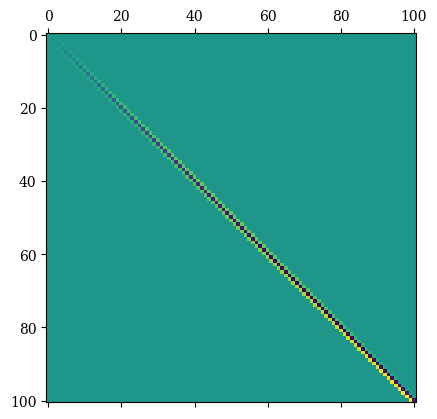

In [95]:
f, ax = plt.subplots()

ax.matshow(rMatrix(44, 100))

plt.show()

In [96]:
def simulate(N, A, stoptime, init):
    """return solution to kolmogorov equations given value for N, how long to simulate, and initial condition
    if init is "max", Ng(0) = A
    if init is "eq", Ng(0) is the equilibrium value from the deterministic model
    """
    #R matrix for give value of N
    r_matrix = rMatrix(N, A)

    #initial value
    p0 = np.zeros(A+1)
    if init == "max":
        p0[A]=1
    elif init == "eq":
        p0[int(A-N*R/K)]=1
    else:
        raise ValueError("init must be \"max\" or \"eq\"")

    #RHS of the system
    def sys(t, y):
        return np.matmul(y, r_matrix)
        
    st = time.time()
    
    s = sp.integrate.solve_ivp(sys, (0, stoptime), p0)
    
    print("finished solution N={0}, A={1}, Ng0 {2} in {3:.2f} seconds".format(N, A, init, time.time()-st))
    return s

## Execute simulations

## Save and load simulation results
because running the sims takes unpleasantly long

In [97]:
with open("kolmogorov_sol_max_100.dat", "rb") as f:
    sol_max_100 = pickle.load(f)

with open("kolmogorov_sol_eq_100.dat", "rb") as f:
    sol_eq_100 = pickle.load(f)

with open("kolmogorov_sol_max_500.dat", "rb") as f:
    sol_max_500 = pickle.load(f)

with open("kolmogorov_sol_eq_500.dat", "rb") as f:
    sol_eq_500 = pickle.load(f)

## Functions necessary for further investigation

In [9]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [10]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

## Plot evolution of probability distribution as a function of time

In [11]:
def evolutionPlot(a, sol, times):
    """on the axes a, plot the distribution of sol at times t
    returns list of line2ds representing plotted data
    """

    lines = []
    for i in times:
        lines.append(
            #append lines2d pointer to list
            a.plot(sol["y"][:,timeToIndex(sol["t"],i)],
            label="t={0:.0f}".format(i))[0])
    return lines

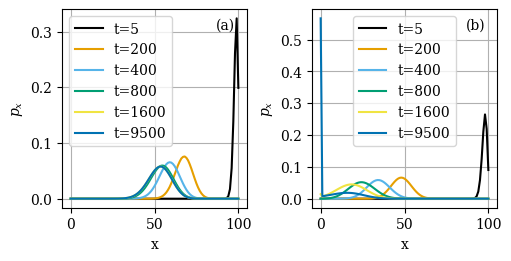

In [12]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 2.5), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

times = [5, 200, 400, 800, 1600, 9500]

evolutionPlot(ax1, sol_max_100["40"], times)
evolutionPlot(ax2, sol_max_100["70"], times)

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
    ax.set_xlabel("x")
    ax.set_ylabel("$p_x$")

plt.savefig("evolution.pdf")

## Plot expected value and variance as a function of time

In [13]:
def expPlot(a, sol):
    """plot expected value of sol as a function of time
    returns line2d representing the plotted data"""

    expval = np.array([
        pmfE(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], expval)

def varPlot(a, sol):
    """plot the variance of sol as a function of time
    returns line2d representing the plotted data"""

    vars = np.array([
        pmfVar(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], vars)

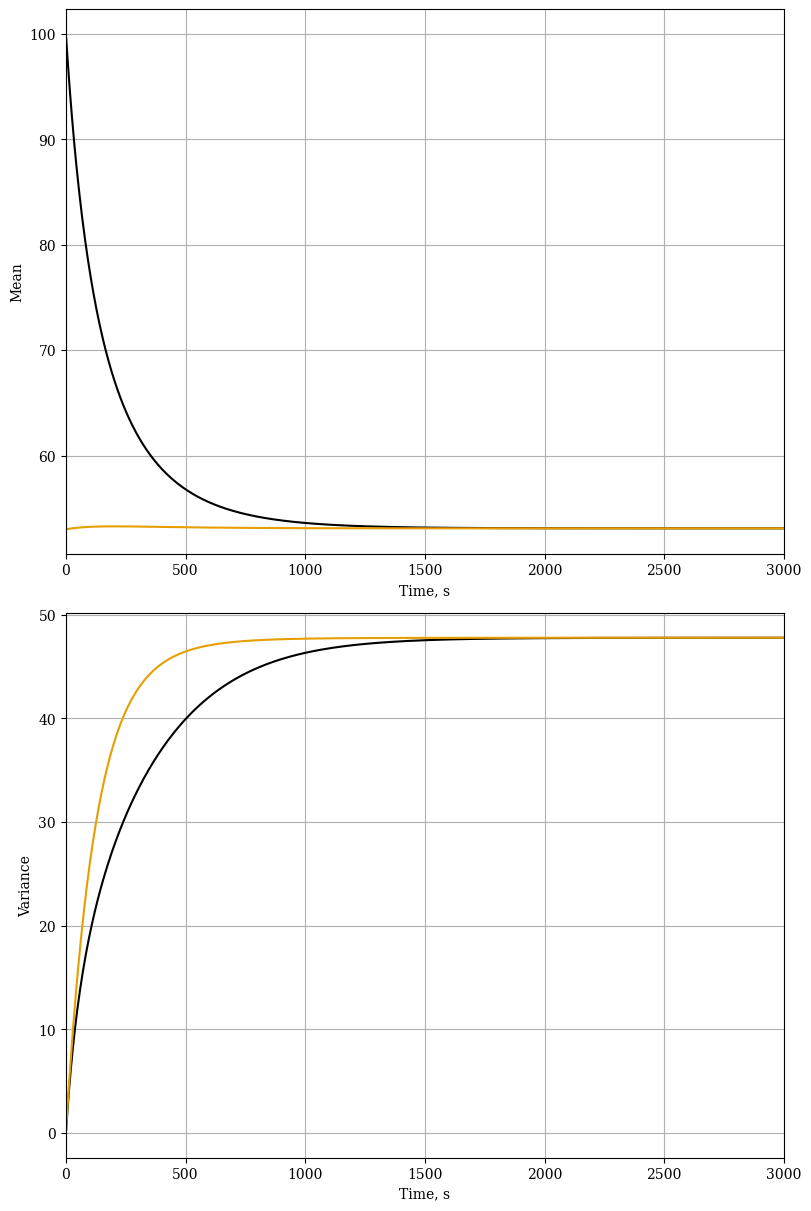

In [14]:
f, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 12), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

pt1 = expPlot(ax1, sol_max_100["40"])
pt2 = expPlot(ax1, sol_eq_100["40"])

pt3 = varPlot(ax2, sol_max_100["40"])
pt4 = varPlot(ax2, sol_eq_100["40"])

ax1.grid(True)
ax1.set_xlabel("Time, s")
ax1.set_ylabel("Mean")
ax1.set_xlim([0, 3000])

ax2.grid(True)
ax2.grid(True)
ax2.set_xlabel("Time, s")
ax2.set_ylabel("Variance")
ax2.set_xlim([0, 3000])

plt.show()

## Plot extinction probability as a function of time

In [15]:
def p0Plot(a, sol):
    return a.plot(sol["t"], sol["y"][0,:])

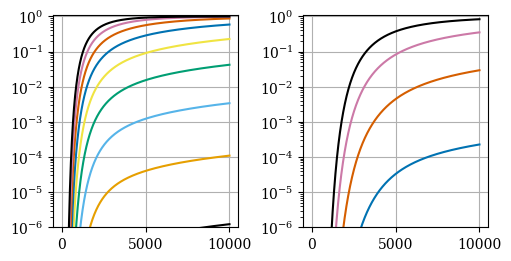

In [16]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 2.5), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

#keys_100 = ["45", "50", "70", "85"]

for i in list(sol_max_100.keys()):
    p0Plot(ax1, sol_max_100[i])

for i in list(sol_max_500.keys()):
    p0Plot(ax2, sol_max_500[i])

ax1.grid(True)
ax2.grid(True)

ax1.set_yscale("log")
ax2.set_yscale("log")

ax1.set_ylim([10**-6, 1.1])
ax2.set_ylim([10**-6, 1.1])

plt.show()

## Plot equilibrium distribution for different sheep numbers

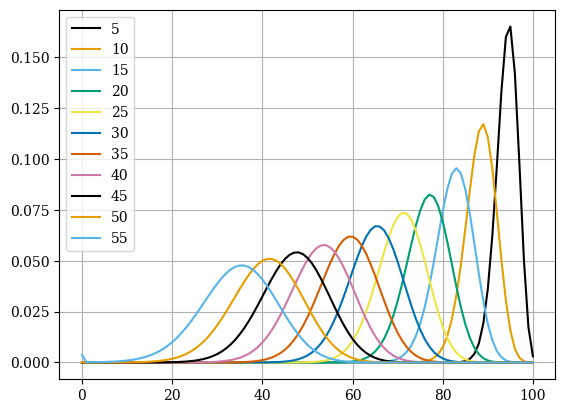

In [17]:
f, ax = plt.subplots()

ax.set_prop_cycle(wong_cycle)

for i in list(sol_eq_100.keys())[0:11]:
    ax.plot(sol_eq_100[i]["y"][:,-1], label=i)

ax.grid(True)
#ax.set_ylim([-0.01, 0.20])
ax.legend()

plt.show()

## Plot expected grass population after 10k seconds as a function of sheep number

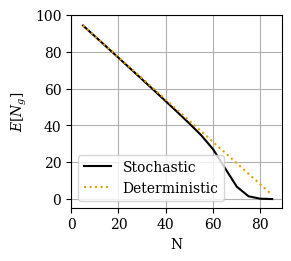

In [26]:
N_A = np.array([int(k) for k in list(sol_max_100.keys())])

det_N_g_100 = np.array(100 - N_A*R/K)

e_10k_100 = np.array([
    pmfE(sol_max_100[k]["y"][:,-1]) for k in list(sol_max_100.keys())
])

f, ax = plt.subplots(layout="constrained", figsize=(2.8, 2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(N_A, e_10k_100, "-", label="Stochastic")
ax.plot(N_A, det_N_g_100, ":", label="Deterministic")

ax.grid(True)
ax.legend()
ax.set_xlabel("N")
ax.set_ylabel("$E[N_g]$")
ax.set_xlim(left=0)
ax.set_ylim(top=100)

plt.savefig("expected_N_g_vs_N.pdf")

## Mean time to extinction

In [28]:
def meanExt(N, A):
    """calculate the mean time to extinction for a pasture of size A and sheep population N"""

    r_mod = rMatrix(N, A)[1:,1:]

    m = -np.linalg.inv(r_mod)

    return np.sum(m[-1,:])

large extinction times will cause errors somewhere here - my theory is that `np.linalg.inv()` uses 32 bit floats and starts running into scale limits

In [29]:
N_list_100 = np.arange(85, 35, -1)
N_list_500 = np.arange(425, 300, -5)

mean_ext_100 = np.array([meanExt(i, 100) for i in N_list_100])
mean_ext_500 = np.array([meanExt(i, 500) for i in N_list_500])

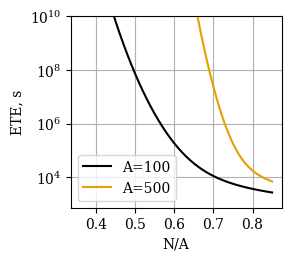

In [34]:
f, ax = plt.subplots(layout="constrained", figsize=(2.8, 2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(N_list_100/100, mean_ext_100, "-", label="A=100")
ax.plot(N_list_500/500, mean_ext_500, "-", label="A=500")

ax.set_yscale("log")

ax.set_ylim(top=10**10)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8])
ax.grid(True)
ax.legend()
ax.set_ylabel("ETE, s")
ax.set_xlabel("N/A")

plt.savefig("ext_time.pdf")

## Quasi-equillibrium distribution

### Recurrence relation method

M. S. Bartlett, J. C. Gower, and P. H. Leslie, A comparison of theoretical and empirical results for some stochastic population models, Biometrika 47: 1-11 (1960)

$$p_x\mu_x=p_{x-1}\lambda_{x-1}$$

$$p_x\mu_x-p_{x-1}\lambda_{x-1}=0$$

for $2\leq x\leq A$

so we will have

$$p_2\mu_2-p_1\lambda_1 = 0$$
$$p_3\mu_3-p_2\lambda_2 = 0$$
$$\dots$$
$$p_A\mu_A-p_{A-1}\lambda_{A-1}=0$$

we also have the equation

$$\sum_{x=1}^{A}p_x=1$$

we will have a system of A equations and A variables

In [99]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    return np.linalg.solve(mat, b)

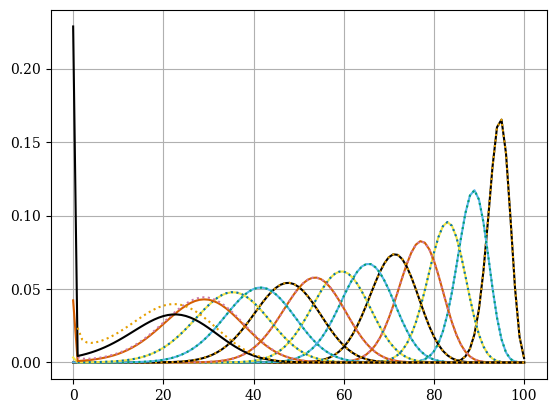

In [115]:
f, ax = plt.subplots()

ax.set_prop_cycle(wong_cycle)

for i in list(sol_max_100.keys())[0:13]:
    ax.plot(sol_max_100[i]["y"][:,-1])
    ax.plot(np.arange(1, 101), quasiEqRec(100, int(i)), ":")
    

ax.grid(True)

plt.show()

### Modified R matrix method
As seen in matis & kiffe textbook chapter six appendix 6.2.8.1

i have not been able to get this to work.

In [78]:
def quasiEqR(A, N):
    r_mod = rMatrix(N, A)[1:,1:]
    #set mu_1=0 in the r11 element
    r_mod[0,0]=-growthRate(1, N, A)
    
    return np.linalg.solve(r_mod, np.zeros(r_mod.shape[0]))

In [84]:
r = rMatrix(5, 20)[1:,1:]
r[0,0] = -growthRate(1, 20, 5)

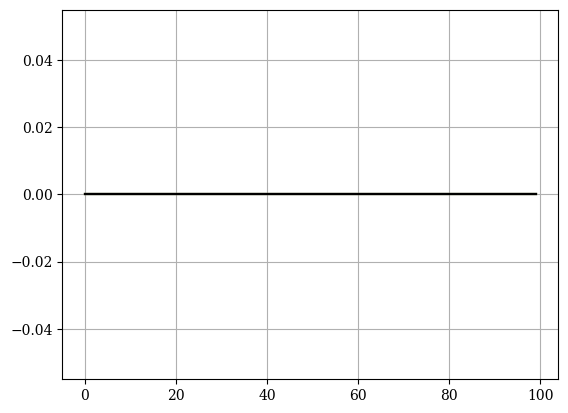

In [80]:
f, ax = plt.subplots()

ax.set_prop_cycle(wong_cycle)

for i in range(5, 50, 5):
    ax.plot(quasiEqR(100, i))

ax.grid(True)

plt.show()